# Анализ данных Яндекс Афиша
- Автор: Шагунов А.П.
- Дата: 23.08.2026

## Цели и задачи проекта

**Цель проекта:** на основании данных сервиса Яндекс Aфиша за период с 1.06.2024 по 31.10.2024 г. изучить изменение пользовательской активности или пользовательского интереса в связи с сезонностью (осень vs лето). Изучение будет проводится в разрезе типов мероприятий, типов устройств и категорий мероприятий по возрастному рейтингу.

**Задачи проекта:**
1. Загрузить данные и провести первичное знакомство с ними, оценить объём, состав и корректность датасетов.
2. Провести предобработку данных: проверить пропуски, дубликаты (явные и неявные), скорректировать типы данных, обработать выбросы в revenue и tickets_count.
3. Создать новые признаки (revenue_rub, one_ticket_revenue_rub, month, season) для дальнейшего анализа.
4. Проанализировать распределение заказов по сегментам и их сезонные изменения — изучить динамику количества заказов по месяцам, сравнить структуру заказов летом и осенью в разрезе типа мероприятия, типа устройства и возрастной категории, а также оценить изменение средней выручки с одного билета по типам мероприятий.
5. Исследовать осеннюю активность пользователей — проанализировать динамику заказов, DAU, среднего числа заказов на пользователя и средней стоимости билета по дням, изучить недельную цикличность (будни/выходные).
6. Изучить популярность событий и вклад партнёров — оценить распределение мероприятий и заказов по регионам, а также вклад билетных операторов по числу мероприятий, заказов и выручке.
7. Проверить статистические гипотезы об активности пользователей мобильных и стационарных устройств: сравнить среднее количество заказов на пользователя и среднее время между заказами по типам устройств, используя данные за осенний период.
8. Сформулировать общие выводы и рекомендации для продуктовой команды на основе результатов анализа и проверки гипотез.

## Описание данных 

Датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Он содержит следующие поля:

- `order_id` — уникальный идентификатор заказа.  
- `user_id` — уникальный идентификатор пользователя.  
- `created_dt_msk` — дата создания заказа (московское время).  
- `created_ts_msk` — дата и время создания заказа (московское время).  
- `event_id` — идентификатор мероприятия из таблицы events.  
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.  
- `age_limit` — возрастное ограничение мероприятия.  
- `currency_code` — валюта оплаты, например rub для российских рублей.  
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.  
- `revenue` — выручка от заказа.  
- `service_name` — название билетного оператора.  
- `tickets_count` — количество купленных билетов.  
- `total`— общая сумма заказа.  
- `days_since_prev` - количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.  


Датасет `final_tickets_events_df` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Он содержит следующие поля:
- `event_id` — уникальный идентификатор мероприятия.  
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.  
- `event_type_description` — описание типа мероприятия.  
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.  
- `organizers` — организаторы мероприятия.  
- `region_name` — название региона.  
- `city_name` — название города.  
- `venue_id` — уникальный идентификатор площадки.  
- `venue_name` — название площадки.  
- `venue_address` — адрес площадки.   


Справочный датасет `final_tickets_tenge_df.csv` содержит информацию о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Он содержит следующие поля:
- `nominal` — номинал (100 тенге).  
- `data` — дата.  
- `curs` — курс тенге к рублю.  
- `cdx` — обозначение валюты (kzt).

## Содержимое проекта   


1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Статистический анализ данных.
5. Итоговый вывод и рекомендации.

## 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
from scipy import stats
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные в переменные orders_df, events_df и tenge_df
orders_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
events_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
tenge_df=pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [3]:
orders_df.info()
display(orders_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


**Промежуточный вывод по orders_df:**<br>
- В датафрейме 290 849 строк.  
- Данные не содержат пропусков, кроме столбца `days_since_prev`, но это корректно, т.к. если покупки не было, то данные содержат пропуск.
- Необходимо привести столбцы `created_dt_msk` и `created_ts_msk` к типу данных "datetime", столбец `days_since_prev` к целочисленному типу данных "integer".  Для оптимизации памяти также следует произвести снижение размерности у столбцов `age_limit` и `tickets_count`.

In [4]:
events_df.info()
display(events_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


**Промежуточный вывод по events_df:**<br>
- В датафрейме 22 427 строк.  
- Данные не содержат пропусков.
- Преобразование типов данных не требуется.

In [5]:
tenge_df.info()
display(tenge_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


**Промежуточный вывод по tenge_df:**<br>
- В датафрейме 357 строк.  
- Данные не содержат пропусков.
- Столбец `data` надо привести к типу данных "datetime".

## 2. Предобработка данных.

### Преобразование типов данных

In [6]:
# Приводим в порядок типы данных в orders_df
orders_df['created_dt_msk'] = pd.to_datetime(orders_df['created_dt_msk'])
orders_df['created_ts_msk'] = pd.to_datetime(orders_df['created_ts_msk'])

orders_df['days_since_prev'] = orders_df['days_since_prev'].astype('Int16')

orders_df['age_limit'] = pd.to_numeric(orders_df['age_limit'], downcast='integer')
orders_df['tickets_count'] = pd.to_numeric(orders_df['tickets_count'], downcast='integer')

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290849 non-null  int64         
 1   user_id                290849 non-null  object        
 2   created_dt_msk         290849 non-null  datetime64[ns]
 3   created_ts_msk         290849 non-null  datetime64[ns]
 4   event_id               290849 non-null  int64         
 5   cinema_circuit         290849 non-null  object        
 6   age_limit              290849 non-null  int8          
 7   currency_code          290849 non-null  object        
 8   device_type_canonical  290849 non-null  object        
 9   revenue                290849 non-null  float64       
 10  service_name           290849 non-null  object        
 11  tickets_count          290849 non-null  int8          
 12  total                  290849 non-null  floa

In [7]:
# Приводим в порядок типы данных в tenge_df
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 11.3+ KB


### Объединение датафреймов и проверка

In [8]:
# Объединяем orders_df и events_df
df = orders_df.merge(events_df, on='event_id', how='left')

# Проверяем, что все event_id из orders_df нашли соответствие в events_df
missing_events = df['event_type_main'].isna().sum()
print(f'Заказов без данных о мероприятии: {missing_events}')

df.info()

Заказов без данных о мероприятии: 238
<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290849 non-null  int64         
 1   user_id                 290849 non-null  object        
 2   created_dt_msk          290849 non-null  datetime64[ns]
 3   created_ts_msk          290849 non-null  datetime64[ns]
 4   event_id                290849 non-null  int64         
 5   cinema_circuit          290849 non-null  object        
 6   age_limit               290849 non-null  int8          
 7   currency_code           290849 non-null  object        
 8   device_type_canonical   290849 non-null  object        
 9   revenue                 290849 non-null  float64       
 10  service_name            290849 non-null  object        
 11  tickets_count           290849 non-null  int8        

In [9]:
# Выделяем заказы без данных о мероприятии
missing_mask = df['event_type_main'].isna()
missing_orders = df[missing_mask]

print(f'Количество "потерянных" event_id: {missing_orders["event_id"].nunique()}')
print(f'Количество заказов: {missing_orders.shape[0]}')
print()

# Смотрим, есть ли эти event_id вообще в events_df
missing_event_ids = missing_orders['event_id'].unique()
print('Примеры "потерянных" event_id:', missing_event_ids[:10])
print()

# Проверяем как расрпеделяются заказы по разным категориям
print('Распределение по service_name:')
display(missing_orders['service_name'].value_counts())

print('Распределение по device_type_canonical:')
display(missing_orders['device_type_canonical'].value_counts())

print('Диапазон дат заказов без мероприятия:')
print(missing_orders['created_dt_msk'].min(), '-', missing_orders['created_dt_msk'].max())

Количество "потерянных" event_id: 19
Количество заказов: 238

Примеры "потерянных" event_id: [533222 530296 532300 477731 536716 246804 536731 555671 548224 538260]

Распределение по service_name:


Билеты без проблем    190
Лучшие билеты          21
Билеты в руки          21
Мой билет               4
Лови билет!             2
Name: service_name, dtype: int64

Распределение по device_type_canonical:


mobile     189
desktop     49
Name: device_type_canonical, dtype: int64

Диапазон дат заказов без мероприятия:
2024-06-01 00:00:00 - 2024-10-30 00:00:00


In [57]:
# Проверка на наличие не явных дубликатов в столбцах с категориальными значениями
categorical_columnss = [
    'cinema_circuit', 'currency_code', 'device_type_canonical', 'service_name',
    'age_limit', 'event_type_description', 'event_type_main',
    'region_name', 'city_name'
]

for col in categorical_columnss:
    print(f'--- {col} ---')
    print(f'Количество уникальных значений: {df[col].nunique()}')
    print(sorted(df[col].dropna().unique().astype(str)))
    print()

--- cinema_circuit ---
Количество уникальных значений: 6
['Другое', 'КиноСити', 'Киномакс', 'Москино', 'ЦентрФильм', 'нет']

--- currency_code ---
Количество уникальных значений: 2
['kzt', 'rub']

--- device_type_canonical ---
Количество уникальных значений: 2
['desktop', 'mobile']

--- service_name ---
Количество уникальных значений: 36
['Crazy ticket!', 'Show_ticket', 'Билет по телефону', 'Билеты без проблем', 'Билеты в интернете', 'Билеты в руки', 'Быстробилет', 'Быстрый кассир', 'Весь в билетах', 'Восьмёрка', 'Вперёд!', 'Выступления.ру', 'Городской дом культуры', 'Дом культуры', 'Дырокол', 'За билетом!', 'Зе Бест!', 'КарандашРУ', 'Кино билет', 'Край билетов', 'Лимоны', 'Лови билет!', 'Лучшие билеты', 'Мир касс', 'Мой билет', 'Облачко', 'Прачечная', 'Радио ticket', 'Реестр', 'Росбилет', 'Тебе билет!', 'Телебилет', 'Тех билет', 'Цвет и билет', 'Шоу начинается!', 'Яблоко']

--- age_limit ---
Количество уникальных значений: 5
['0', '12', '16', '18', '6']

--- event_type_description ---

In [11]:
share = missing_orders.shape[0] / df.shape[0] * 100
print(f'Доля заказов без данных о мероприятии: {share:.3f}%')

Доля заказов без данных о мероприятии: 0.082%


In [12]:
df = df[~missing_mask].reset_index(drop=True)

print(f'Итоговый размер df: {df.shape[0]} строк, {df.shape[1]} столбцов')
print(f'Пропуски в event_type_main после удаления: {df["event_type_main"].isna().sum()}')

Итоговый размер df: 290611 строк, 24 столбцов
Пропуски в event_type_main после удаления: 0


**Промежуточный вывод:**<br>
После объединения orders_df и events_df было обнаружено 238 заказов без данных о типе мероприятия (`event_type_main`).<br>
Эти заказы относятся к разным мероприятим, билетным операторам и платформам. Делаем вывод, что они имеют случайный характер.<br>
Доля таких заказов составялет 0.082% от общего объема.<br>
Принято решение удалить эти заказы, т.к. объем не материальный.

### Проверка распределения и наличия выбросов

In [13]:
# Разделяем на рубли и тенге
df_rub = df[df['currency_code'] == 'rub']
df_kzt = df[df['currency_code'] == 'kzt']

print(f'\nЗаказов в рублях: {df_rub.shape[0]}')
print(f'Заказов в тенге: {df_kzt.shape[0]}')


Заказов в рублях: 285542
Заказов в тенге: 5069


In [14]:
print('revenue, руб — статистика:')
display(df_rub['revenue'].describe())

print('revenue, тенге — статистика:')
display(df_kzt['revenue'].describe())

print('tickets_count (заказы в руб) — статистика:')
display(df_rub['tickets_count'].describe())

print('tickets_count (заказы в тенге) — статистика:')
display(df_kzt['tickets_count'].describe())

revenue, руб — статистика:


count    285542.000000
mean        548.013929
std         871.750181
min         -90.760000
25%         114.170000
50%         346.630000
75%         793.320000
max       81174.540000
Name: revenue, dtype: float64

revenue, тенге — статистика:


count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64

tickets_count (заказы в руб) — статистика:


count    285542.000000
mean          2.754159
std           1.171575
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

tickets_count (заказы в тенге) — статистика:


count    5069.000000
mean        2.762872
std         1.115558
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: tickets_count, dtype: float64

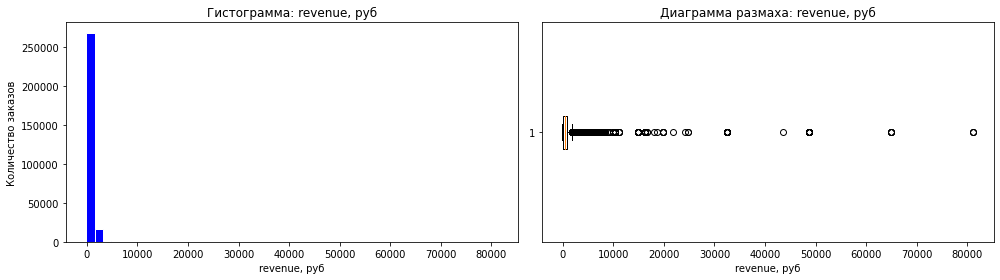

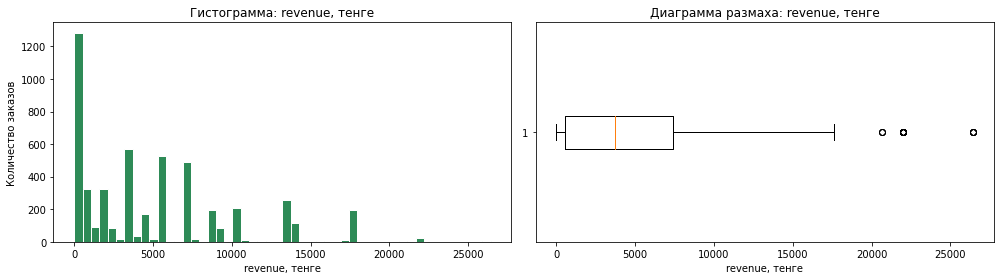

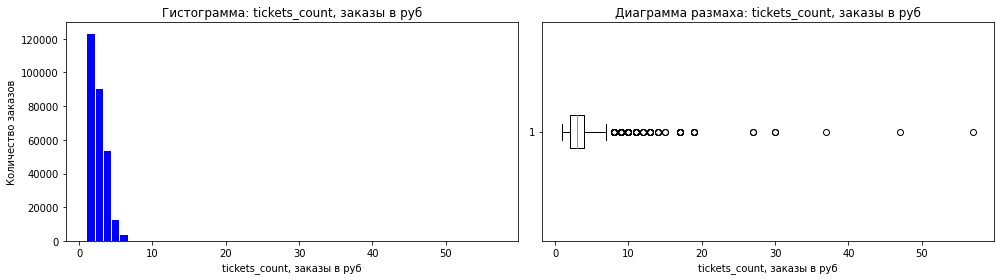

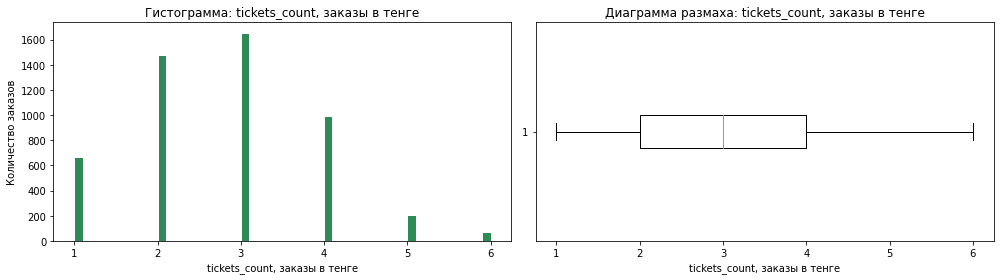

In [15]:
def plot_distribution(series, title, bins=50, color='blue'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(series, bins=bins, color=color, edgecolor='white')
    axes[0].set_title(f'Гистограмма: {title}')
    axes[0].set_xlabel(title)
    axes[0].set_ylabel('Количество заказов')

    axes[1].boxplot(series, vert=False)
    axes[1].set_title(f'Диаграмма размаха: {title}')
    axes[1].set_xlabel(title)

    plt.tight_layout()
    plt.show()

plot_distribution(df_rub['revenue'], 'revenue, руб')
plot_distribution(df_kzt['revenue'], 'revenue, тенге', color='seagreen')
plot_distribution(df_rub['tickets_count'], 'tickets_count, заказы в руб')
plot_distribution(df_kzt['tickets_count'], 'tickets_count, заказы в тенге', color='seagreen')

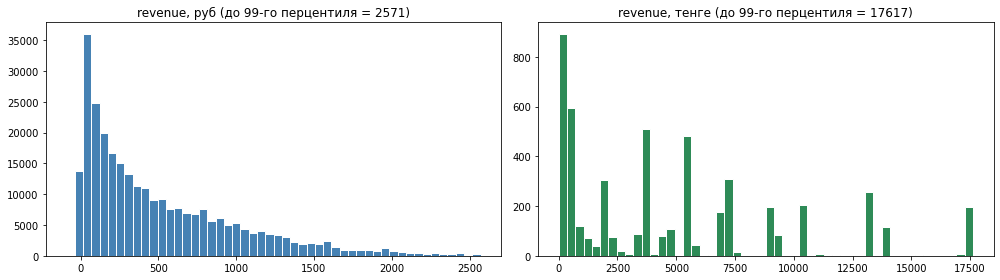

Заказов выше 99-го перцентиля (руб): 2800 (0.98%)
Заказов выше 99-го перцентиля (тенге): 29 (0.57%)


In [16]:
# Гистограммы, обрезанные по 99-му перцентилю (для наглядности)
p99_rub = df_rub['revenue'].quantile(0.99)
p99_kzt = df_kzt['revenue'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_rub.loc[df_rub['revenue'] <= p99_rub, 'revenue'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'revenue, руб (до 99-го перцентиля = {p99_rub:.0f})')
axes[1].hist(df_kzt.loc[df_kzt['revenue'] <= p99_kzt, 'revenue'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title(f'revenue, тенге (до 99-го перцентиля = {p99_kzt:.0f})')
plt.tight_layout()
plt.show()

# Доля и количество заказов выше 99-го перцентиля
outliers_rub = (df_rub['revenue'] > p99_rub).sum()
outliers_kzt = (df_kzt['revenue'] > p99_kzt).sum()
print(f'Заказов выше 99-го перцентиля (руб): {outliers_rub} ({outliers_rub/df_rub.shape[0]*100:.2f}%)')
print(f'Заказов выше 99-го перцентиля (тенге): {outliers_kzt} ({outliers_kzt/df_kzt.shape[0]*100:.2f}%)')

In [17]:
# Фильтруем выбросы по 99-му перцентилю, отдельно для руб и тенге
p99_rub = df_rub['revenue'].quantile(0.99)
p99_kzt = df_kzt['revenue'].quantile(0.99)

df_rub_filtered = df_rub[df_rub['revenue'] <= p99_rub]
df_kzt_filtered = df_kzt[df_kzt['revenue'] <= p99_kzt]

print(f'Удалено заказов (руб): {df_rub.shape[0] - df_rub_filtered.shape[0]}')
print(f'Удалено заказов (тенге): {df_kzt.shape[0] - df_kzt_filtered.shape[0]}')

# Собираем df обратно из отфильтрованных частей
df = pd.concat([df_rub_filtered, df_kzt_filtered], ignore_index=True)

print(f'\nИтоговый размер df: {df.shape[0]} строк')

Удалено заказов (руб): 2800
Удалено заказов (тенге): 29

Итоговый размер df: 287782 строк


In [18]:
# Проверим заказы с отрицательная и нулевой выручкой
neg_rub = (df_rub['revenue'] < 0).sum()
zero_rub = (df_rub['revenue'] == 0).sum()
zero_kzt = (df_kzt['revenue'] == 0).sum()

print(f'Отрицательная revenue (руб): {neg_rub} заказов')
print(f'Нулевая revenue (руб): {zero_rub} заказов')
print(f'Нулевая revenue (тенге): {zero_kzt} заказов')

print('\nПримеры заказов с отрицательной/нулевой revenue (руб):')
display(df_rub[df_rub['revenue'] <= 0][['order_id', 'revenue', 'tickets_count', 'total', 'service_name']].head(10))

print('\nПримеры заказов с нулевой revenue (тенге):')
display(df_kzt[df_kzt['revenue'] == 0][['order_id', 'revenue', 'tickets_count', 'total', 'service_name']].head(10))

Отрицательная revenue (руб): 381 заказов
Нулевая revenue (руб): 5520 заказов
Нулевая revenue (тенге): 6 заказов

Примеры заказов с отрицательной/нулевой revenue (руб):


,order_id,revenue,tickets_count,total,service_name
24,3253250,0.00,3,0.0,Билеты без проблем
65,4130442,0.00,1,0.0,Билеты без проблем
66,4130500,0.00,1,0.0,Билеты без проблем
67,4130471,0.00,1,0.0,Билеты без проблем
68,4130529,0.00,1,0.0,Билеты без проблем
252,1594653,-2.37,3,-59.2,Билеты без проблем
517,4797152,0.00,2,0.0,Билеты без проблем
519,5227628,0.00,3,0.0,Билеты без проблем
695,4616018,0.00,2,0.0,Билеты без проблем
696,4616076,0.00,3,0.0,Билеты без проблем



Примеры заказов с нулевой revenue (тенге):


,order_id,revenue,tickets_count,total,service_name
232958,1121112,0.0,1,0.0,Мой билет
232959,1121170,0.0,1,0.0,Мой билет
232960,1121141,0.0,3,0.0,Мой билет
232961,1121199,0.0,2,0.0,Мой билет
265771,4693709,0.0,3,0.0,Мой билет
265772,7537565,0.0,3,0.0,Мой билет


In [19]:
# Проверим заказы с большим количеством билетов
print('Распределение tickets_count по убыванию:')
display(df_rub['tickets_count'].value_counts().sort_index(ascending=False).head(15))

print('\nПримеры заказов с наибольшим tickets_count:')
display(df_rub.sort_values('tickets_count', ascending=False)[['order_id', 'revenue', 'tickets_count', 'total', 'service_name']].head(10))

Распределение tickets_count по убыванию:


57     1
47     1
37     1
30     2
27     2
19     5
17     6
15     2
14     4
13     7
12     4
11    13
10    19
9     38
8     21
Name: tickets_count, dtype: int64


Примеры заказов с наибольшим tickets_count:


,order_id,revenue,tickets_count,total,service_name
154010,3526517,0.00,57,0.00,Билеты без проблем
39416,5338292,640.41,47,32020.47,Билеты без проблем
154586,8151843,1147.67,37,19127.89,Билеты в руки
154186,3526575,0.00,30,0.00,Билеты без проблем
154183,3526633,0.00,30,0.00,Билеты без проблем
86274,5190653,328.49,27,10949.60,Лови билет!
86271,5190682,328.49,27,10949.60,Лови билет!
153315,806259,1926.71,19,38534.28,Мой билет
154182,3526546,0.00,19,0.00,Билеты без проблем
190445,3091430,190.06,19,9502.85,Билеты без проблем


**Промежуточный вывод:**<br>
- В данных есть заказы с отрицательной выручкой - это скорее всего возвраты, не трогаем их.
- Есть заказы с нулевой выручкой и нулевой общей суммой заказа, скороее всего это акционные, бесплатные или тестовые билеты. Их тоже не трогаем.
- Количество билетов в заказе распределено нормально. Есть заказы с большим количеством билетов (57) - скорее всего это групповые заказы, например, для школьного класса.
- На диаграмме размаха для выручки в рублях видны выбросы. mean = 548.01, median = 346.63 - среднее почти в 1,6 раза больше медианы, это признак правосторонней асимметрии. std = 871.75 при mean = 548.01 - стандартное отклонение больше среднего. Выручка в тенге распределена более равномерно, но также видны выборосы на диаграмме и среднее в 1,3 раза больше медианы.
- Для устранения выбросов были отобраны значения по 99-му процентилю для обеих валют. Было отброшено меньше 1% заказов.


### Проверка на явные и неявные дубликаты

In [20]:
# Проверим на явные дубликаты (полностью совпадающие строки)
explicit_dup = df.duplicated().sum()
print(f'Явных дубликатов (полное совпадение строк): {explicit_dup}')

Явных дубликатов (полное совпадение строк): 0


In [21]:
# Проверим неявные дубликаты, где есть совпадение по всем полям, кроме order_id
# (то есть по сути одно и то же бронирование, оформленное дважды под разными order_id)
cols_no_id = [col for col in df.columns if col != 'order_id']

implicit_dup_mask = df.duplicated(subset=cols_no_id, keep=False)
implicit_dup = df[implicit_dup_mask]

print(f'Заказов, попадающих в неявные дубликаты: {implicit_dup.shape[0]}')
print(f'Количество дублей: {df.duplicated(subset=cols_no_id, keep="first").sum()}')

# Смотрим на примеры, отсортировав по ключевым полям, чтобы увидеть дубли рядом
display(
    implicit_dup.sort_values(cols_no_id)
    [['order_id', 'user_id', 'created_ts_msk', 'event_id', 'revenue', 'tickets_count', 'total', 'service_name', 'device_type_canonical']]
    .head(20)
)

Заказов, попадающих в неявные дубликаты: 58
Количество дублей: 30


,order_id,user_id,created_ts_msk,event_id,revenue,tickets_count,total,service_name,device_type_canonical
11484,1123983,06eb7897f65b433,2024-08-13 16:31:07,183706,69.82,1,997.48,Билеты в руки,mobile
11485,1123867,06eb7897f65b433,2024-08-13 16:31:07,183706,69.82,1,997.48,Билеты в руки,mobile
55803,160922,2564e3703075008,2024-10-30 10:04:15,589005,11.23,2,280.81,Лови билет!,mobile
55806,160893,2564e3703075008,2024-10-30 10:04:15,589005,11.23,2,280.81,Лови билет!,mobile
81716,3363711,3ee7dc2e115847f,2024-06-25 07:32:08,277504,59.19,3,739.85,Билеты в руки,mobile
81721,3363798,3ee7dc2e115847f,2024-06-25 07:32:08,277504,59.19,3,739.85,Билеты в руки,mobile
144378,2324032,7b525118ae656af,2024-10-28 08:33:04,588203,26.96,4,674.12,Лучшие билеты,mobile
144382,2323916,7b525118ae656af,2024-10-28 08:33:04,588203,26.96,4,674.12,Лучшие билеты,mobile
149902,5372628,7eb4fc207ecc10f,2024-08-23 14:08:19,298035,126.84,1,3170.95,Билеты без проблем,mobile
149905,5372831,7eb4fc207ecc10f,2024-08-23 14:08:19,298035,126.84,1,3170.95,Билеты без проблем,mobile


In [22]:
# Удаляем неявные дубликаты бронирования (одинаковые данные, кроме order_id)
# Оставляем первую запись в каждой группе дублей
before = df.shape[0]
df = df.drop_duplicates(subset=cols_no_id, keep='first').reset_index(drop=True)
after = df.shape[0]

print(f'Удалено дублирующихся заказов: {before - after}')

Удалено дублирующихся заказов: 30


**Промежуточный вывод после проверки на дубликаты:**<br>
- Явных дубликатов не выявлено
- Выявлено и удалено 30 заказов-неявных дубликатов. В них совпадали все поля: один и тот же пользователь, то же время создания заказа с точностью до секунды, совпадают событие, выручка, количество билетов, сумма заказа, партнёр, устройство. Отличается только order_id.<br>
Скорее всего это технические дубли: повторная отправка формы, из-за которой система создала два/три отдельных order_id для одной и той же покупки.

### Добавляем новые столбцы

Столбец `revenue_rub` с выручкой с заказа в единой валюте — российскоих рублях. Так как курс дан «в рублях за 100 тенге», то для заказов в тенге нужно умножить revenue на curs / nominal.

In [23]:
# Выделяем заказы в тенге для конвертации
kzt_orders = df[df['currency_code'] == 'kzt'].copy()

# Объеденям их с данными tenge_df по дате заказа
kzt_orders = kzt_orders.merge(
    tenge_df[['data', 'curs', 'nominal']],
    left_on='created_dt_msk', right_on='data',
    how='left')

# Конвертируем revenue в рубли по курсу на дату заказа
kzt_orders['revenue_rub'] = kzt_orders['revenue'] * kzt_orders['curs'] / kzt_orders['nominal']

# Для рублей: revenue_rub совпадает с revenue
rub_orders = df[df['currency_code'] == 'rub'].copy()
rub_orders['revenue_rub'] = rub_orders['revenue']

# Собираем обратно единый df
df = pd.concat(
    [rub_orders, kzt_orders.drop(columns=['data', 'curs', 'nominal'])],
    ignore_index=True
)

print(f'Итоговый размер df: {df.shape[0]} строк')

print('\nПроверка на пропуски в revenue_rub:')
print(df['revenue_rub'].isna().sum())

Итоговый размер df: 287752 строк

Проверка на пропуски в revenue_rub:
0


Столбец `one_ticket_revenue_rub` — выручка с продажи одного билета на мероприятие.

In [24]:
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

Столбец `month` — месяц оформления заказа.

In [25]:
df['month'] = df['created_dt_msk'].dt.month

Столбец `season` — информация о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

In [26]:
conditions = [
    df['month'].isin([12, 1, 2]),    # зима: декабрь, январь, февраль
    df['month'].isin([3, 4, 5]),     # весна: март, апрель, май
    df['month'].isin([6, 7, 8]),     # лето: июнь, июль, август
    df['month'].isin([9, 10, 11])    # осень: сентябрь, октябрь, ноябрь
]

choices = ['зима', 'весна', 'лето', 'осень']

df['season'] = np.select(conditions, choices, default='неизвестный')

In [27]:
# Проверим созданные столбцы
display(df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,<NA>,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1521.94,380.4850,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,<NA>,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",289.45,144.7250,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.57,314.6425,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,<NA>,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",8.49,4.2450,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.41,463.4700,10,осень


### Вывод по разделу с предообработкой данных

Было предобработано и объединено 2 датасета `orders_df` и `events_df`:
- Исправлены и оптимизированы типы данных.
- Удалено 238 заказов без данных о типе мероприятия.
- Устранены выбросы в обеих валютах, отобранные по 99-му процентилю. Было отброшено меньше 1% заказов.
- Проведена проверка на явные и неявные дубликаты. Выявлено и удалено 30 заказов-неявных дубликатов.
- Для дальнейшей аналитики были добавлены новые столбцы: `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`.

## 3. Исследовательский анализ данных

 ### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

#### Количество заказов по месяцам

,month,orders_count,month_name
0,6,34164,июнь
1,7,40407,июль
2,8,44550,август
3,9,69352,сентябрь
4,10,99279,октябрь


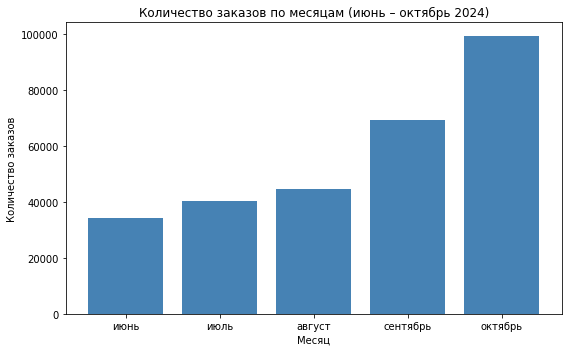

In [28]:
month_names = {6: 'июнь', 7: 'июль', 8: 'август', 9: 'сентябрь', 10: 'октябрь', 11: 'ноябрь'}

monthly_orders = df.groupby('month').size().reset_index(name='orders_count')
monthly_orders['month_name'] = monthly_orders['month'].map(month_names)

display(monthly_orders)

# Визуализация
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(monthly_orders['month_name'], monthly_orders['orders_count'], color='steelblue')
ax.set_title('Количество заказов по месяцам (июнь – октябрь 2024)')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество заказов')
plt.tight_layout()
plt.show()

**Промежуточный вывод:**<br>
Количество заказов растёт каждый месяц. От 34 164 в июне до 99 279 в октябре, рост в 3 раза за 5 месяцев. Заметен явный скачок в сентябре (+56% к августу) - начало осени резко ускоряет динамику, рост продолжается в октябре (+43% к сентябрю).

#### Сравнение распределения заказов билетов по категориям для осеннего и летнего периодов

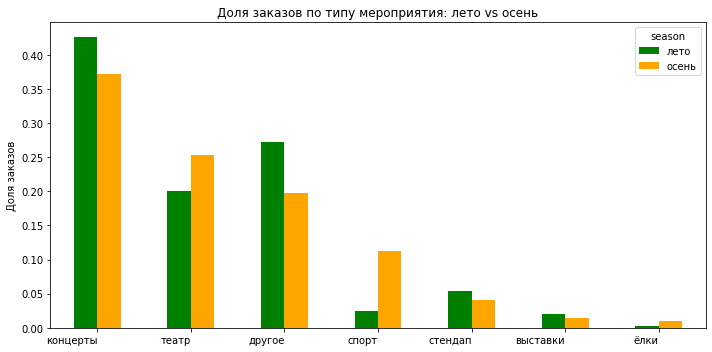

season,лето,осень
event_type_main,,
концерты,0.43,0.37
театр,0.20,0.25
другое,0.27,0.20
спорт,0.03,0.11
стендап,0.05,0.04
выставки,0.02,0.01
ёлки,0.00,0.01


In [29]:
# Функция считает долю заказов по категориям сегмента отдельно для лета и осени
def season_share_by_segment(data, segment_col):
    shares = (
        data.groupby('season')[segment_col]
        .value_counts(normalize=True)
        .rename('share')
        .reset_index()
    )
    return shares.sort_values([segment_col, 'season'])

def plot_season_share(data, segment_col, title):
    shares = season_share_by_segment(data, segment_col)
    pivot = shares.pivot(index=segment_col, columns='season', values='share').fillna(0)
    pivot = pivot.sort_values('осень', ascending=False)

    ax = pivot.plot(kind='bar', figsize=(10, 5), color=['green', 'orange'])
    ax.set_title(title)
    ax.set_ylabel('Доля заказов')
    ax.set_xlabel('')
    plt.xticks(rotation=0, ha='right')
    plt.tight_layout()
    plt.show()

    return pivot.round(2)

pivot_event_type = plot_season_share(df, 'event_type_main', 'Доля заказов по типу мероприятия: лето vs осень')
display(pivot_event_type)

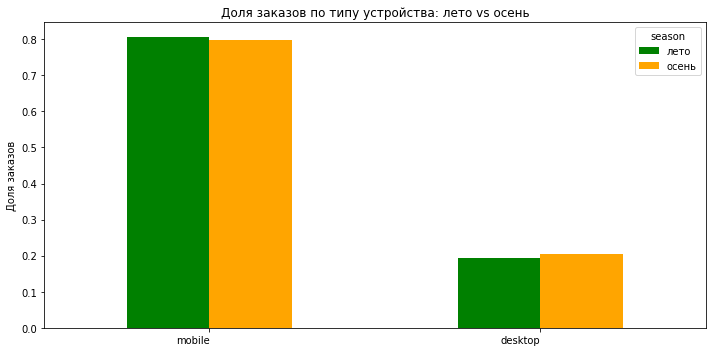

season,лето,осень
device_type_canonical,,
mobile,0.81,0.8
desktop,0.19,0.2


In [30]:
pivot_device = plot_season_share(df, 'device_type_canonical', 'Доля заказов по типу устройства: лето vs осень')
display(pivot_device)

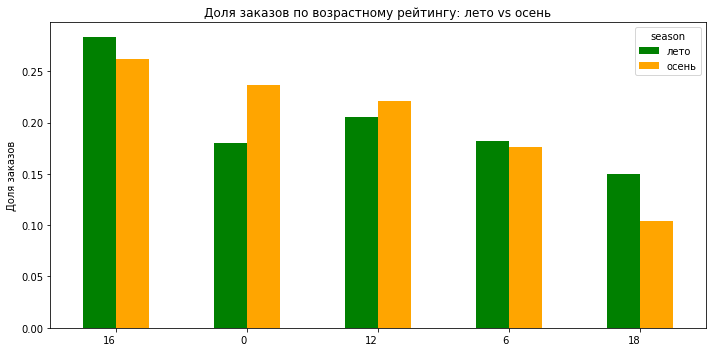

season,лето,осень
age_limit,,
16,0.28,0.26
0,0.18,0.24
12,0.21,0.22
6,0.18,0.18
18,0.15,0.10


In [31]:
pivot_age = plot_season_share(df, 'age_limit', 'Доля заказов по возрастному рейтингу: лето vs осень')
display(pivot_age)

**Промежуточный вывод:**<br>
- По типу мероприятия прослеживается сезонность:
    - Спорт: 0.03 → 0.11 - почти четырёхкратный рост, самый резкий сдвиг среди всех типов. Осенью спортивные мероприятия становятся куда заметнее в структуре заказов.
    - Концерты: 0.43 → 0.37 и «другое»: 0.27 → 0.20 - оба типа теряют долю осенью, но концерты все равно остаются самыми популярными мероприятиями.
    - Театр: 0.20 → 0.25 - рост на 5 п.п., обсуловлен началом театрального сезона.
    - Выставки: 0.02 → 0.01 - маленькая категория, несущественные измнения.
    - Ёлки: 0.00 → 0.01 - начинают появляться заказы на новогодние мероприятия уже в октябре.

- По типу устройства: различия между летом и осенью и в mobile и в desktop составили по 1 п.п. - сезонность никак не влияет на выбор устройства.

- По возрастному рейтингу:
    - 0+: 0.18 → 0.24 - заметный рост доли семейных мероприятий (+33% относительно летнего уровня).
    - 18+: 0.15 → 0.10 - доля упала на треть, самое сильное изменение. Обсуловлено ростом 0+.
    - Остальные категории (6+, 12+, 16+) без существенных изменений.

#### Изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью

season,лето,осень,change_pct
event_type_main,,,
стендап,218.52,231.12,5.77
выставки,86.42,90.60,4.85
спорт,50.76,49.97,-1.56
другое,77.43,76.12,-1.70
концерты,304.79,268.36,-11.95
ёлки,271.44,229.59,-15.42
театр,214.14,175.97,-17.82


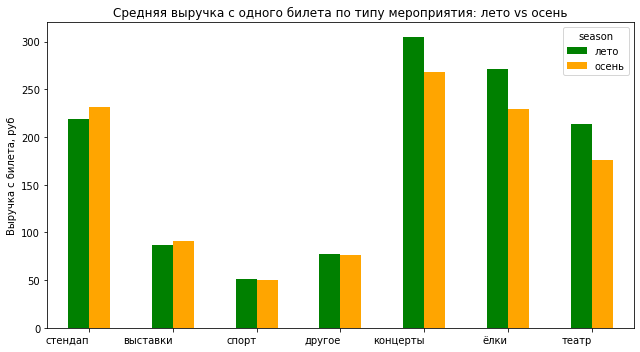

In [32]:
# Средняя выручка с одного билета по типу мероприятия и сезону
revenue_by_type = (
    df.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub']
    .mean()
    .unstack('season')
)

# Относительное изменение осень к лету
revenue_by_type['change_pct'] = (
    (revenue_by_type['осень'] - revenue_by_type['лето']) / revenue_by_type['лето'] * 100
)

revenue_by_type = revenue_by_type.round(2).sort_values('change_pct', ascending=False)
display(revenue_by_type)

# Визуализация
fig, ax = plt.subplots(figsize=(9, 5))
revenue_by_type[['лето', 'осень']].plot(kind='bar', ax=ax, color=['green', 'orange'])
ax.set_title('Средняя выручка с одного билета по типу мероприятия: лето vs осень')
ax.set_ylabel('Выручка с билета, руб')
ax.set_xlabel('')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

**Промежуточный вывод по изменение выручки с одного билета (лето vs осень):**<br>
Картина неоднородная:
- Осенью стали **дороже** билеты на следующие типы мероприятий:
    - стендап (+5.8%),
    - выставки (+4.9%).<br>
Обе эти категории незначительно теряют долю в структуре заказов.
- Осенью стали **дешевле** билеты на следующие типы мероприятий:
    - театр (-17.8%) - самое большое падение,
    - ёлки (-15.4%),
    - концерты (-12.0%).
    
- Спорт и «другое» - почти без изменений (-1.6% и -1.7%).


#### Промежуточный вывод по разделу 3.1:

**Динамика заказов по месяцам:**<br>
Количество заказов монотонно растёт каждый месяц с 34 164 в июне до 99 279 в октябре (почти x3). Наиболее резкий скачок в сентябре по отрошению к августу (+56%), что явно отражает начало осеннего сезона. В октябре рост продолжается (+43% к сентябрю).

**Изменение структуры заказов по сегментам (лето → осень):**<br>
- *Тип мероприятия* - **доля спорта выросла почти в 4 раза** (0.03 → 0.11). Также заметно **выросла доля театра** (0.20 → 0.25), появились **ёлки** (0.00 → 0.01). При этом доля **концертов** (0.43 → 0.37) и категории **«другое»** (0.27 → 0.20) снизилась, хотя концерты остаются самым популряным типом мероприятий.
- *Тип устройства* на сезонность не влияет.
- *Возрастной рейтинг* - доля семейного контента 0+ выросла на треть (0.18 → 0.24), а доля 18+ на столько же снизилась (0.15 → 0.10). Осенняя аудитория смещается в сторону более широкой, семейной аудитории.

**Изменение выручки с одного билета (лето → осень):**<br>
Четкой тенденции нет, средняя выручка у одних типов мепроприятий растёт, у других падает.
Осенью выросла выручка с стендапов (+5.8%) и выставок (+4.9%), упала с театра (-17.8%), ёлок (-15.4%) и концертов (-12.0%).
Цена билетов на спортивные мероприятия и в категории «другое» почти без изменений (-1.6% и -1.7%).

**Важное наблюдение:** рост доли театра сопровождается заметным падением средней цены билета (-17.8%) - это говорит о том, что рост популярности театра осенью, вероятно, связан с более доступными билетами, постановками и расширением аудитории. У спорта, напротив, четырёхкратный рост доли заказов произошёл без изменения цены билета, то есть весь прирост выручки в этой категории идёт исключительно за счёт объёма заказов, а не роста среднего чека.

 ### 3.2. Осенняя активность пользователей

Проанализируем динамику изменений по дням для:
- общего числа заказов;
- количества активных пользователей DAU;
- среднего числа заказов на одного пользователя;
- средней стоимости одного билета.

In [33]:
# Оставляем только осенние данные
autumn_df = df[df['season'] == 'осень'].copy()

print(f'Заказов осенью: {autumn_df.shape[0]}')

Заказов осенью: 168631


In [34]:
# Сводная таблица по дням
daily_stats = autumn_df.groupby('created_dt_msk').agg(
    orders_count=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
).reset_index()

# Заказов на одного пользователя
daily_stats['orders_per_user'] = daily_stats['orders_count'] / daily_stats['dau']

display(daily_stats.head())

,created_dt_msk,orders_count,dau,avg_ticket_price,orders_per_user
0,2024-09-01,1327,564,200.168708,2.352837
1,2024-09-02,1380,574,189.464639,2.404181
2,2024-09-03,5113,778,80.350151,6.571979
3,2024-09-04,1773,686,178.048069,2.584548
4,2024-09-05,1944,739,189.510156,2.630582


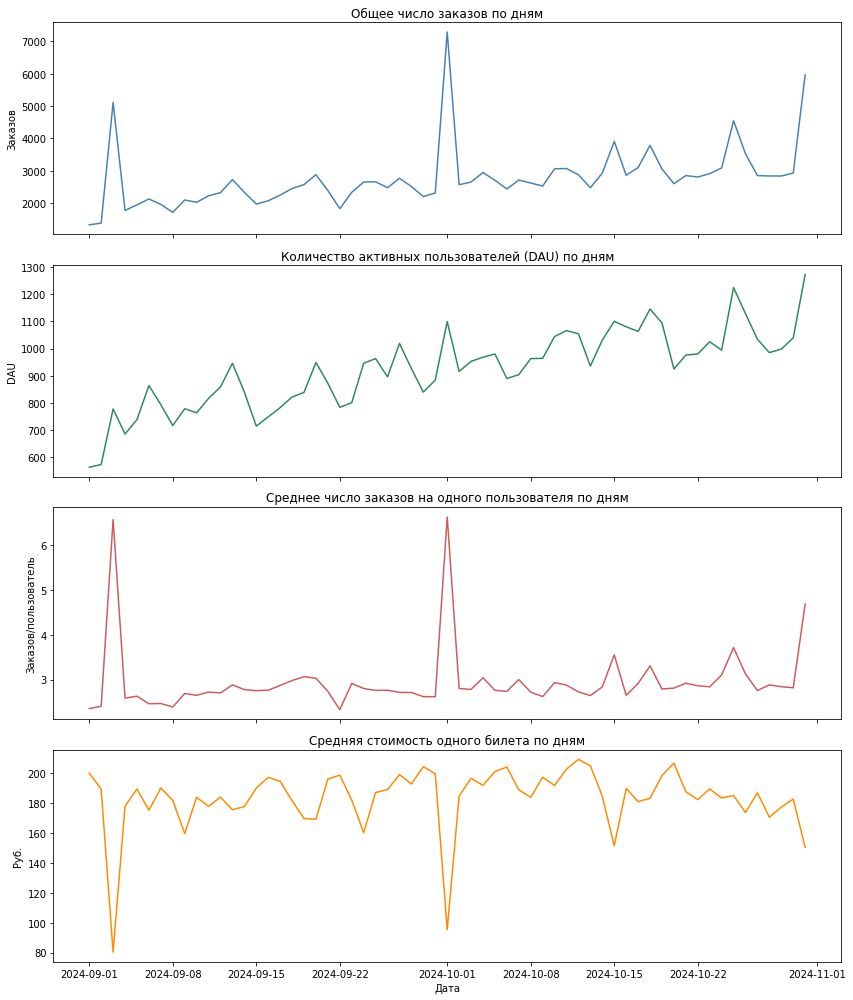

In [35]:
# Визуализация динамики по дням
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

axes[0].plot(daily_stats['created_dt_msk'], daily_stats['orders_count'], color='steelblue')
axes[0].set_title('Общее число заказов по дням')
axes[0].set_ylabel('Заказов')

axes[1].plot(daily_stats['created_dt_msk'], daily_stats['dau'], color='seagreen')
axes[1].set_title('Количество активных пользователей (DAU) по дням')
axes[1].set_ylabel('DAU')

axes[2].plot(daily_stats['created_dt_msk'], daily_stats['orders_per_user'], color='indianred')
axes[2].set_title('Среднее число заказов на одного пользователя по дням')
axes[2].set_ylabel('Заказов/пользователь')

axes[3].plot(daily_stats['created_dt_msk'], daily_stats['avg_ticket_price'], color='darkorange')
axes[3].set_title('Средняя стоимость одного билета по дням')
axes[3].set_ylabel('Руб.')
axes[3].set_xlabel('Дата')

plt.tight_layout()
plt.show()

**Промежуточный вывод о динамике показателей по дням:**<br>
- **DAU** демонстрирует устойчивый рост на протяжении всего периода - с ~550 пользователей в начале сентября до ~1250 в конце октября (более чем в 2 раза), с выраженной недельной цикличностью.
- **Общее число заказов** также растёт вместе с DAU, но с тремя резкими аномальными всплесками (3 сентября, 1 октября, 31 октября), когда количество заказов подскакивало в 3-4 раза относительно обычного уровня.
- Все три всплеска **совпадают с провалом средней стоимости одного билета** (до ~80 руб. при обычных 180–200 руб.) и скачком заказов на одного пользователя (до ~6 при обычных ~2-3) - это указывает на массовые распродажи или акции в конкретные дни, а не на органический рост спроса.
- Без учёта этих трех дней динамика всех показателей выглядит стабильной: рост DAU, стабильный рост общего числа заказов, умеренный рост заказов на пользователя (с ~2 до ~3) и относительно стабильная средняя цена билета (180–200 руб.).

Изучим недельную цикличность. Выделим день недели и сравним пользовательскую активность в будни и выходные.

In [36]:
# Определяем день недели
daily_stats['weekday'] = daily_stats['created_dt_msk'].dt.day_name()
daily_stats['weekday_num'] = daily_stats['created_dt_msk'].dt.dayofweek  # 0 = понедельник
daily_stats['is_weekend'] = daily_stats['weekday_num'] >= 5
display(daily_stats.head())

,created_dt_msk,orders_count,dau,avg_ticket_price,orders_per_user,weekday,weekday_num,is_weekend
0,2024-09-01,1327,564,200.168708,2.352837,Sunday,6,True
1,2024-09-02,1380,574,189.464639,2.404181,Monday,0,False
2,2024-09-03,5113,778,80.350151,6.571979,Tuesday,1,False
3,2024-09-04,1773,686,178.048069,2.584548,Wednesday,2,False
4,2024-09-05,1944,739,189.510156,2.630582,Thursday,3,False


In [37]:
# Проверим, на какие дни недели пришлись аномальные всплески (акции)
spike_days = daily_stats.sort_values('orders_count', ascending=False).head(3)
print('Дни с аномальным всплеском заказов (акции):')
display(spike_days[['created_dt_msk', 'weekday', 'orders_count']])

Дни с аномальным всплеском заказов (акции):


,created_dt_msk,weekday,orders_count
30,2024-10-01,Tuesday,7289
60,2024-10-31,Thursday,5961
2,2024-09-03,Tuesday,5113


In [38]:
# Сравнение будни vs выходные (все дни, включая акции)
print('Включая дни с акциями:')
weekend_compare = daily_stats.groupby('is_weekend')[['orders_count', 'dau', 'orders_per_user', 'avg_ticket_price']].mean().round(2)
weekend_compare.index = weekend_compare.index.map({True: 'выходные', False: 'будни'})
display(weekend_compare)

# Проверка без дней с акциями
spike_dates = spike_days['created_dt_msk'].tolist()
daily_stats_clean = daily_stats[~daily_stats['created_dt_msk'].isin(spike_dates)]

weekend_compare_clean = daily_stats_clean.groupby('is_weekend')[['orders_count', 'dau', 'orders_per_user', 'avg_ticket_price']].mean().round(2)
weekend_compare_clean.index = weekend_compare_clean.index.map({True: 'выходные', False: 'будни'})
print('Без учёта дней с акциями:')
display(weekend_compare_clean)

Включая дни с акциями:


,orders_count,dau,orders_per_user,avg_ticket_price
is_weekend,,,,
будни,2906.77,937.41,3.07,178.61
выходные,2396.06,887.82,2.68,195.22


Без учёта дней с акциями:


,orders_count,dau,orders_per_user,avg_ticket_price
is_weekend,,,,
будни,2671.59,929.20,2.85,183.72
выходные,2396.06,887.82,2.68,195.22


In [59]:
# Средние показатели по каждому дню недели (без учета дней с выбросами-акциями)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_names_ru = {
    'Monday': 'понедельник', 'Tuesday': 'вторник', 'Wednesday': 'среда',
    'Thursday': 'четверг', 'Friday': 'пятница', 'Saturday': 'суббота', 'Sunday': 'воскресенье'
}

weekday_stats = daily_stats_clean.groupby('weekday')[['orders_count', 'dau', 'orders_per_user', 'avg_ticket_price']].mean()
weekday_stats = weekday_stats.reindex(weekday_order)
weekday_stats.index = weekday_stats.index.map(weekday_names_ru)
weekday_stats = weekday_stats.round(2)

display(weekday_stats)

,orders_count,dau,orders_per_user,avg_ticket_price
weekday,,,,
понедельник,2390.56,853.67,2.78,184.49
вторник,2726.86,933.43,2.90,176.34
среда,2543.44,923.56,2.75,185.49
четверг,2650.75,923.38,2.86,185.71
пятница,3104.38,1022.62,3.00,185.36
суббота,2667.75,961.00,2.76,192.50
воскресенье,2154.56,822.78,2.60,197.64


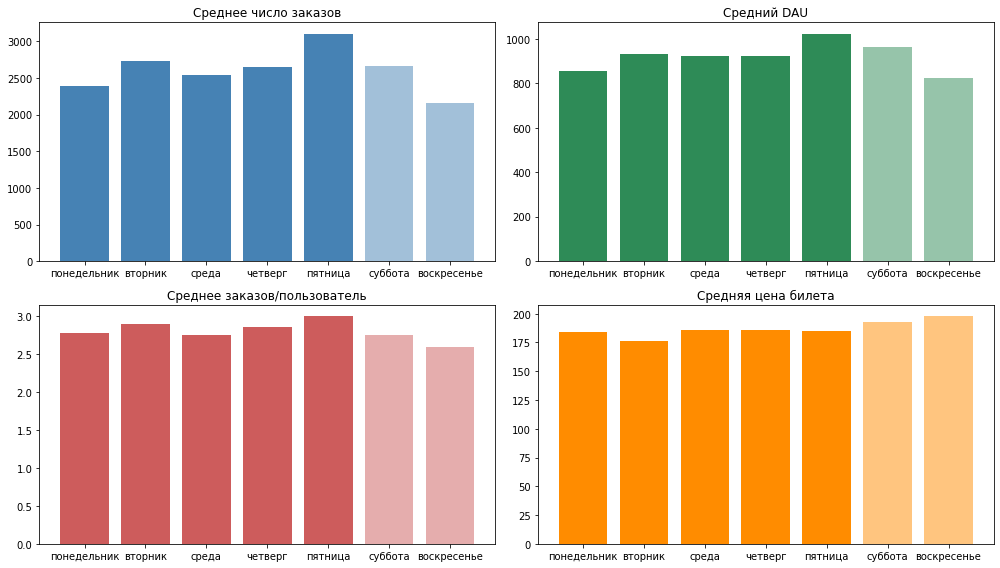

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
metrics = ['orders_count', 'dau', 'orders_per_user', 'avg_ticket_price']
titles = ['Среднее число заказов', 'Средний DAU', 'Среднее заказов/пользователь', 'Средняя цена билета']
colors = ['steelblue', 'seagreen', 'indianred', 'darkorange']

for ax, metric, title, color in zip(axes.flat, metrics, titles, colors):
    bars = ax.bar(weekday_stats.index, weekday_stats[metric], color=color)
    # Выделяем выходные другим цветом для наглядности
    for i, day in enumerate(weekday_stats.index):
        if day in ['суббота', 'воскресенье']:
            bars[i].set_alpha(0.5)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Промежуточный вывод по недельной цикличности после исключения дней с выбросами/акциями:**<br>

**Сравнение будних и выходных дней показывает:**
- **Число заказов**: будни выше на ~11.5% (2671.59 vs 2396.06)
- **DAU**: будни выше на ~4.7% (929.20 vs 887.82)
- **Заказы на одного пользователя**: будни выше на ~6.3% (2.85 vs 2.68)
- **Средняя цена билета**: выходные выше на ~6.3% (195.22 vs 183.72 руб.)

Активность пользователей в будни стабильно выше, чем в выходные. Это объясняется тем, что большинство событий происходит в пятницу или выходные, а людя, планируя свой отдых, покупают билеты заранее в течение будних дней.<br>
При этом средний чек за билет выше именно в выходные - возможно в выходные (прямо перед мероприятием, а не заранее покупают оставшиеся более дорогие/премиальные билеты, чтобы успеть на событие.

**Детализация по дням недели показывает:**
- Пятница - пик активности по всем показателям: максимум заказов (3104), DAU (1023) и заказов на пользователя (3) среди всех дней недели, включая выходные. Пользователи активно покупают билеты на предстоящие выходные именно в пятницу.
- Остальные будние дни не выделяются и не отличаются между собой.
- Воскресенье - минимум активности: 2155 заказов, DAU 823, заказов на пользователя 2.6. Это самые низкие значения недели по всем трем метрикам.
- Суббота, напротив, не уступает будням: 2668 заказов и DAU 961 - сопоставимо или выше, чем в понедельник и среду.
- Средняя цена билета плавно растет к концу недели и достигает максимума именно в воскресенье (197.64 руб.) - самый низкий уровень цены, наоборот, во вторник (176.34 руб.). Это подтверждает то, что в воскресенье покупают билеты на мероприятия "здесь и сейчас" (в том числе более дорогие премиальные варианты), в то время как основная масса заказов в будни делается заранее.

**Итог:** недельная цикличность имеет паттерн с пиком в пятницу и спадом в воскресенье, при этом суббота по активности близка к типичному будню. Высокая активность в будни по сравнению с выходными во многом объясняется пиком в пятницу и провалом в воскресенье, а не тем, что все будние дни системно активнее всех выходных.

 ### 3.3. Популярные события и партнёры

Изучим как события распределены по регионам и партнёрам.

In [39]:
# Считаем для каждого региона уникальное количетсво мероприятий и общее число заказов
region_stats = df.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    orders_count=('order_id', 'count')
).reset_index()

# Добавляем доли от общего числа
region_stats['events_share'] = (region_stats['unique_events'] / region_stats['unique_events'].sum() * 100).round(2)
region_stats['orders_share'] = (region_stats['orders_count'] / region_stats['orders_count'].sum() * 100).round(2)

region_stats = region_stats.sort_values('orders_count', ascending=False)

print(f'Всего регионов: {region_stats.shape[0]}')
display(region_stats.head(10))

Всего регионов: 81


,region_name,unique_events,orders_count,events_share,orders_share
23,Каменевский регион,5935,89665,26.54,31.16
60,Североярская область,3800,43739,17.00,15.20
77,Широковская область,1232,16169,5.51,5.62
42,Медовская область,504,13892,2.25,4.83
45,Озернинский край,349,10405,1.56,3.62
57,Светополянский округ,1075,7502,4.81,2.61
41,Малиновоярский округ,165,6314,0.74,2.19
64,Солнечноземская область,522,6278,2.33,2.18
52,Речиновская область,702,6267,3.14,2.18
78,Яблоневская область,535,6123,2.39,2.13


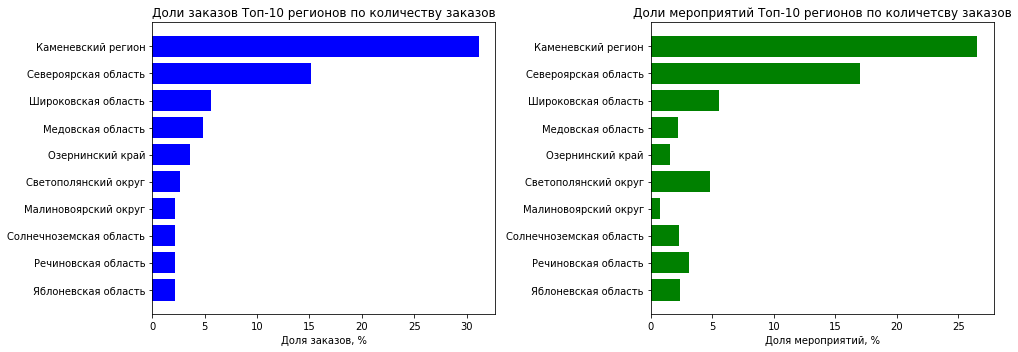

In [40]:
# Визуализация топ-10 регионов по числу заказов
top_regions = region_stats.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_regions['region_name'], top_regions['orders_share'], color='blue')
axes[0].set_title('Доли заказов Топ-10 регионов по количеству заказов')
axes[0].set_xlabel('Доля заказов, %')
axes[0].invert_yaxis()

axes[1].barh(top_regions['region_name'], top_regions['events_share'], color='green')
axes[1].set_title('Доли мероприятий Топ-10 регионов по количетсву заказов')
axes[1].set_xlabel('Доля мероприятий, %')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [41]:
print(f'Доля заказов, приходящаяся на топ-10 регионов: {region_stats.head(10)["orders_share"].sum():.2f}%')
print(f'Доля мероприятий, приходящаяся на топ-10 регионов: {region_stats.head(10)["events_share"].sum():.2f}%')

Доля заказов, приходящаяся на топ-10 регионов: 71.72%
Доля мероприятий, приходящаяся на топ-10 регионов: 66.27%


**Промежуточный вывод:**<br>
Топ-10 регионов по количеству заказов занимают 72% всего рынка заказов и на них приходится 66% всех мероприятий. Эти регионы представлены в таблице.

|        Название региона |Кол-во заказов| Кол-во событий|Доля заказов, %| Доля событий, %|
|------------------------:|-------------:|--------------:|-------------:|-------------:|
|      Каменевский регион |        89665 |          5935 |        31.16 |        26.54 |
|    Североярская область |        43739 |          3800 |        15.20 |        17.00 |
|     Широковская область |        16169 |          1232 |         5.62 |         5.51 |
|       Медовская область |        13892 |           504 |         4.83 |         2.25 |
|        Озернинский край |        10405 |           349 |         3.62 |         1.56 |
|    Светополянский округ |         7502 |          1075 |         2.61 |         4.81 |
|    Малиновоярский округ |         6314 |           165 |         2.19 |         0.74 |
| Солнечноземская область |         6278 |           522 |         2.18 |         2.33 |
|     Речиновская область |         6267 |           702 |         2.18 |         3.14 |
|     Яблоневская область |         6123 |           535 |         2.13 |         2.39 |

Лидером рынка является Каменевский регион: 89,7 тыс. заказов (31%) и 5,9 тыс. мероприятий (27%).

In [42]:
# Считаем для каждого партнёра: уникальные мероприятия, число заказов, суммарную выручку
partner_stats = df.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    orders_count=('order_id', 'count'),
    total_revenue_rub=('revenue_rub', 'sum')
).reset_index()

# Доли от общего числа
partner_stats['events_share'] = (partner_stats['unique_events'] / partner_stats['unique_events'].sum() * 100).round(2)
partner_stats['orders_share'] = (partner_stats['orders_count'] / partner_stats['orders_count'].sum() * 100).round(2)
partner_stats['revenue_share'] = (partner_stats['total_revenue_rub'] / partner_stats['total_revenue_rub'].sum() * 100).round(2)

partner_stats = partner_stats.sort_values('orders_count', ascending=False)

print(f'Всего партнёров: {partner_stats.shape[0]}')
display(partner_stats)

Всего партнёров: 36


,service_name,unique_events,orders_count,total_revenue_rub,events_share,orders_share,revenue_share
3,Билеты без проблем,4247,62858,2.432219e+07,17.42,21.84,16.30
21,Лови билет!,4867,40802,1.667548e+07,19.96,14.18,11.17
5,Билеты в руки,3530,40281,1.319433e+07,14.48,14.00,8.84
24,Мой билет,1300,34440,2.204236e+07,5.33,11.97,14.77
25,Облачко,2335,26402,1.858861e+07,9.58,9.18,12.45
22,Лучшие билеты,1762,17741,2.724061e+06,7.23,6.17,1.83
8,Весь в билетах,855,16425,1.653323e+07,3.51,5.71,11.08
26,Прачечная,1026,10222,4.746811e+06,4.21,3.55,3.18
19,Край билетов,252,6109,6.405689e+06,1.03,2.12,4.29
30,Тебе билет!,1062,5190,2.962303e+06,4.36,1.80,1.98


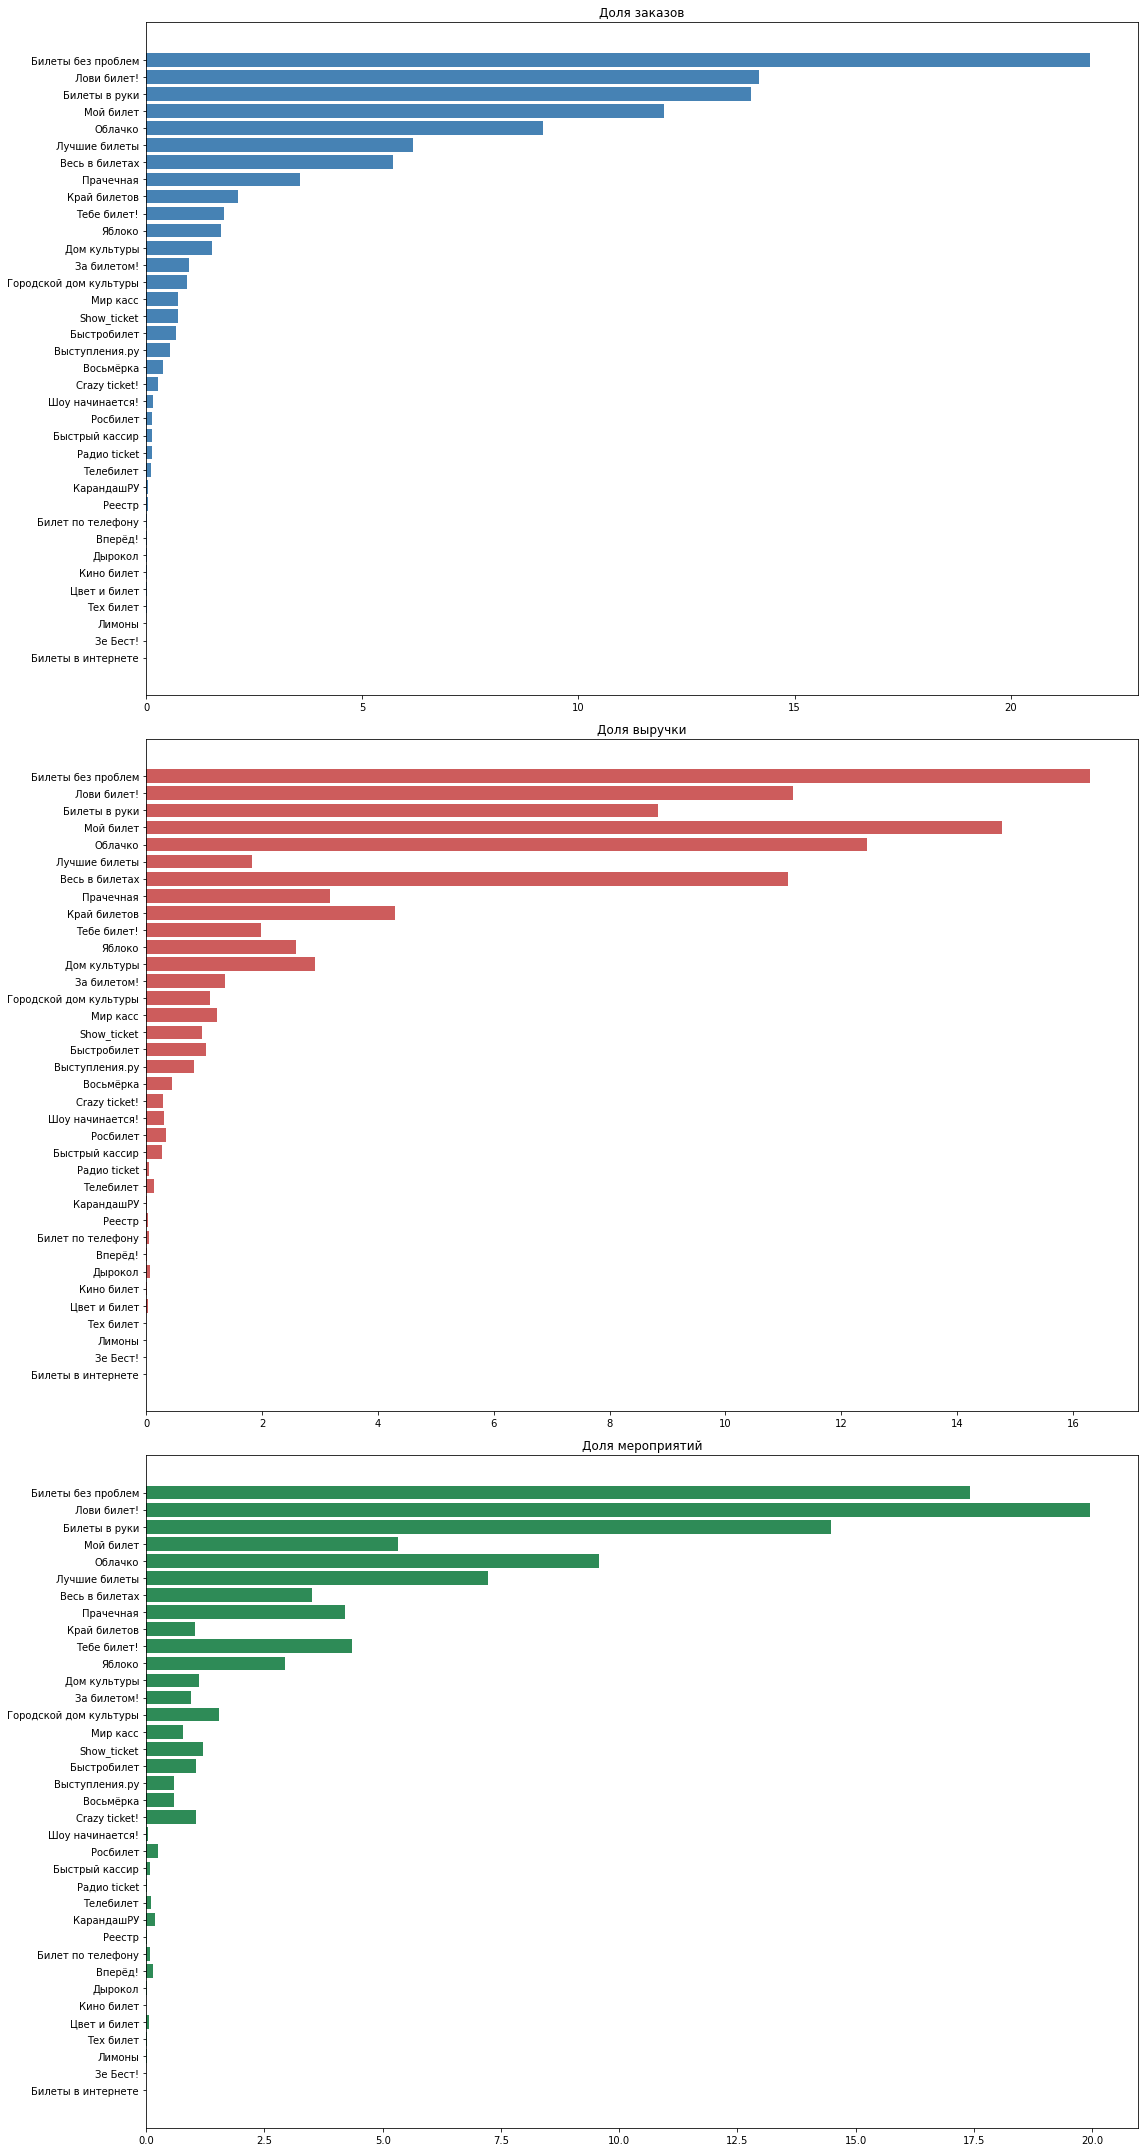

In [43]:
# Визуализация долей по всем трём показателям
fig, axes = plt.subplots(3, 1, figsize=(16, 30))

axes[0].barh(partner_stats['service_name'], partner_stats['orders_share'], color='steelblue')
axes[0].set_title('Доля заказов')
axes[0].invert_yaxis()

axes[1].barh(partner_stats['service_name'], partner_stats['revenue_share'], color='indianred')
axes[1].set_title('Доля выручки')
axes[1].invert_yaxis()

axes[2].barh(partner_stats['service_name'], partner_stats['events_share'], color='seagreen')
axes[2].set_title('Доля мероприятий')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

In [44]:
print(f'Доля заказов, приходящаяся на топ-10 регионов: {partner_stats.head(10)["orders_share"].sum():.2f}%')
print(f'Доля событий, приходящаяся на топ-10 регионов: {partner_stats.head(10)["events_share"].sum():.2f}%')
print(f'Доля выручки, приходящаяся на топ-10 регионов: {partner_stats.head(10)["revenue_share"].sum():.2f}%')

Доля заказов, приходящаяся на топ-10 регионов: 90.52%
Доля событий, приходящаяся на топ-10 регионов: 87.11%
Доля выручки, приходящаяся на топ-10 регионов: 85.89%


**Промежуточный вывод:**<br>
Рынок партнеров состоит из 36 партнеров и сконцентрирован схожим образом с регионами - топ-10 партнеров по числу по заказов дают 91% всех заказов, 87% событий и 86% выручки. Эти партнеры представлены в таблице:

|       service_name | unique_events | orders_count | total_revenue_rub | events_share | orders_share | revenue_share |
|-------------------:|--------------:|-------------:|------------------:|-------------:|-------------:|--------------:|
| Билеты без проблем |          4247 |        62858 |      2.432219e+07 |        17.42 |        21.84 |         16.30 |
|        Лови билет! |          4867 |        40802 |      1.667548e+07 |        19.96 |        14.18 |         11.17 |
|      Билеты в руки |          3530 |        40281 |      1.319433e+07 |        14.48 |        14.00 |          8.84 |
|          Мой билет |          1300 |        34440 |      2.204236e+07 |         5.33 |        11.97 |         14.77 |
|            Облачко |          2335 |        26402 |      1.858861e+07 |         9.58 |         9.18 |         12.45 |
|      Лучшие билеты |          1762 |        17741 |      2.724061e+06 |         7.23 |         6.17 |          1.83 |
|     Весь в билетах |           855 |        16425 |      1.653323e+07 |         3.51 |         5.71 |         11.08 |
|          Прачечная |          1026 |        10222 |      4.746811e+06 |         4.21 |         3.55 |          3.18 |
|       Край билетов |           252 |         6109 |      6.405689e+06 |         1.03 |         2.12 |          4.29 |
|        Тебе билет! |          1062 |         5190 |      2.962303e+06 |         4.36 |         1.80 |          1.98 |
|             Яблоко |           714 |         5004 |      3.868337e+06 |         2.93 |         1.74 |          2.59 |

"Билеты без проблем" - лидер по доле заказов (21.84%) и по доле выручки (16.30%).<br>
"Лови билет!" - на втором месте по заказам (14.18%), но является лидром по доле проводимых мероприятий (19.96%).

**Промежуточный вывод по шагу 3.3:**<br>

**Регионы:** рынок заметно сконцентрирован - топ-10 регионов дают 72% всех заказов и 66% событий. Лидер — Каменевский регион (31% заказов, 27% событий), за ним следует Североярская область (15% заказов, 17% событий).

**Партнёры:** аналогичная ситуация - топ-10 партнеров дают 91% всех заказов, 87% событий и 86% выручки. Компания «Билеты без проблем» - лидер по заказам (21.84%) и выручке (16.30%).

Таким образом, и среди регионов, и среди партнёров есть явные лидеры рынка.

## 4. Статистический анализ данных

**Гипотезы про среднее количество заказов на пользователя**
- Нулевая гипотеза H₀: среднее количество заказов на одного пользователя мобильного приложения не выше, чем у пользователей стационарных устройств.
- Альтернативная гипотеза H₁: среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

**Гипотезы про среднее время между заказами**
- Нулевая гипотеза H₀: среднее время между заказами пользователей мобильных приложений не выше, чем у пользователей стационарных устройств.
- Альтернативная гипотеза H₁: среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

### Проверка гипотезы про среднее количество заказов на пользователя

In [45]:
print(f'Заказов осенью: {autumn_df.shape[0]}')
print(f'Уникальных пользователей осенью: {autumn_df["user_id"].nunique()}')

# Считаем количество заказов на пользователя, отдельно для mobile и desktop
orders_per_user_device = (
    autumn_df.groupby(['user_id', 'device_type_canonical'])['order_id']
    .count()
    .reset_index(name='orders_count')
)

mobile_orders = orders_per_user_device.loc[orders_per_user_device['device_type_canonical'] == 'mobile', 'orders_count']
desktop_orders = orders_per_user_device.loc[orders_per_user_device['device_type_canonical'] == 'desktop', 'orders_count']

print(f'\nПользователей с заказами через mobile: {mobile_orders.shape[0]}')
print(f'Пользователей с заказами через desktop: {desktop_orders.shape[0]}')

# Проверяем пересечение — есть ли пользователи, заказывавшие и с mobile, и с desktop
mobile_users = set(orders_per_user_device.loc[orders_per_user_device['device_type_canonical'] == 'mobile', 'user_id'])
desktop_users = set(orders_per_user_device.loc[orders_per_user_device['device_type_canonical'] == 'desktop', 'user_id'])
overlap = mobile_users & desktop_users

print(f'\nПользователей, заказывавших и с mobile, и с desktop: {len(overlap)}')
print(f'Доля от "мобильных" пользователей: {len(overlap) / len(mobile_users) * 100:.2f}%')
print(f'Доля от "стационарных" пользователей: {len(overlap) / len(desktop_users) * 100:.2f}%')

Заказов осенью: 168631
Уникальных пользователей осенью: 15811

Пользователей с заказами через mobile: 14192
Пользователей с заказами через desktop: 4868

Пользователей, заказывавших и с mobile, и с desktop: 3249
Доля от "мобильных" пользователей: 22.89%
Доля от "стационарных" пользователей: 66.74%


In [46]:
print('Статистика заказов на пользователя (mobile):')
display(mobile_orders.describe())

print('\nСтатистика заказов на пользователя (desktop):')
display(desktop_orders.describe())

Статистика заказов на пользователя (mobile):


count    14192.000000
mean         9.465051
std         68.048019
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       4333.000000
Name: orders_count, dtype: float64


Статистика заказов на пользователя (desktop):


count    4868.000000
mean        7.046631
std        35.987323
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max      1502.000000
Name: orders_count, dtype: float64

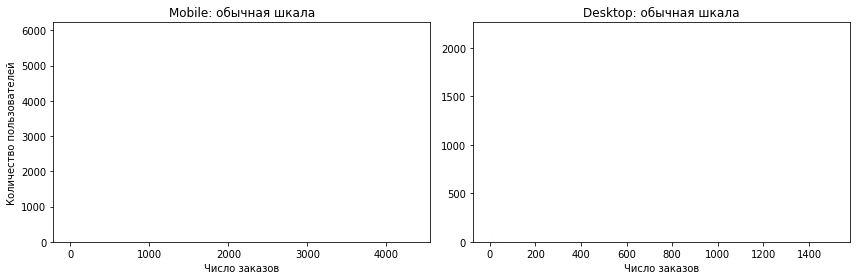

In [47]:
# Гистограмма на линейной шкале
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mobile_orders, bins=range(1, int(mobile_orders.max()) + 2), color='steelblue', edgecolor='white')
axes[0].set_title('Mobile: обычная шкала')
axes[0].set_xlabel('Число заказов')
axes[0].set_ylabel('Количество пользователей')

axes[1].hist(desktop_orders, bins=range(1, int(desktop_orders.max()) + 2), color='seagreen', edgecolor='white')
axes[1].set_title('Desktop: обычная шкала')
axes[1].set_xlabel('Число заказов')

plt.tight_layout()
plt.show()

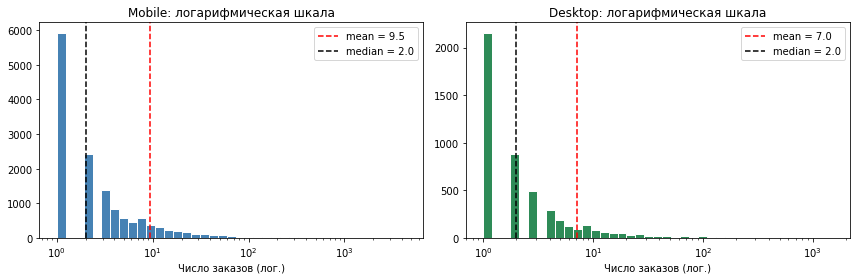

In [48]:
# Гистограмма на логарифмической шкале
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

log_bins_mobile = np.logspace(0, np.log10(mobile_orders.max()), 40)
log_bins_desktop = np.logspace(0, np.log10(desktop_orders.max()), 40)

axes[0].hist(mobile_orders, bins=log_bins_mobile, color='steelblue', edgecolor='white')
axes[0].set_xscale('log')
axes[0].axvline(mobile_orders.mean(), color='red', linestyle='--', label=f'mean = {mobile_orders.mean():.1f}')
axes[0].axvline(mobile_orders.median(), color='black', linestyle='--', label=f'median = {mobile_orders.median():.1f}')
axes[0].set_title('Mobile: логарифмическая шкала')
axes[0].set_xlabel('Число заказов (лог.)')
axes[0].legend()

axes[1].hist(desktop_orders, bins=log_bins_desktop, color='seagreen', edgecolor='white')
axes[1].set_xscale('log')
axes[1].axvline(desktop_orders.mean(), color='red', linestyle='--', label=f'mean = {desktop_orders.mean():.1f}')
axes[1].axvline(desktop_orders.median(), color='black', linestyle='--', label=f'median = {desktop_orders.median():.1f}')
axes[1].set_title('Desktop: логарифмическая шкала')
axes[1].set_xlabel('Число заказов (лог.)')
axes[1].legend()

plt.tight_layout()
plt.show()

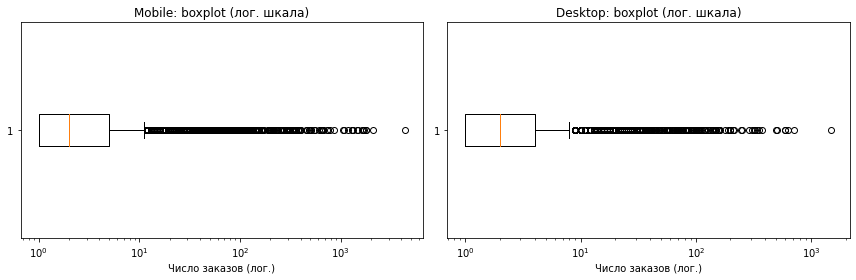

In [49]:
# Диаграмма размаха (boxplot) на логарифмической шкале
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(mobile_orders, vert=False)
axes[0].set_xscale('log')
axes[0].set_title('Mobile: boxplot (лог. шкала)')
axes[0].set_xlabel('Число заказов (лог.)')

axes[1].boxplot(desktop_orders, vert=False)
axes[1].set_xscale('log')
axes[1].set_title('Desktop: boxplot (лог. шкала)')
axes[1].set_xlabel('Число заказов (лог.)')

plt.tight_layout()
plt.show()

**Промежуточный вывод:**<br>
Пользователей с заказами через mobile: 14192.<br>
Пользователей с заказами через desktop: 4868.<br>
Обнаружено 3249 пользователей, заказывавших и с mobile, и с desktop. Это 67% от desktop.<br>
Формально с одной стороны это нарушает предпосылку независимости выборок, но с другой стороны мы можем интерпретировать и обработать обе группы (mobile-заказы одних пользователей vs desktop-заказы других+тех же пользователей) как условно независимые выборки, потмоу что сравниваем именно поведенческий паттерн по типу устройства, а не конкретных непересекающихся людей. Также важно сохранить размер выборки, поэтому пересечение трогать не будем.

У обоих типов устройств среднее в разы больше медианы (mobile: 9.47 vs 2, desktop: 7.05 vs 2).<br>
Стандартное отклонение также в разы больше среднего (mobile: 68 vs 9.47, desktop: 36 vs 7). <br>
График на обычной шкале выглядит пустым из-за ассиметрии. На логорифмической шкале видно настоящую форму распределения: пик на 1-2 заказах и дальше резкое убывание с длинным хвостом, видно правосторонную асимметрию.<br>
На boxplot так же видно большое количество выбросов.
Максимумы в 4333 и 1502 заказа на одного пользователя за ~2 месяца выглядят действительно аномально. Скорее это бот-перекупщик, а не обычный пользователь, который нам интересен.

Итого: данные не распределены нормально. t-тест не подойдёт. Нужно будет отсечь экстремальные значения по 99-му перцентилю, чтобы привести данные в порядок.

Для статистической оценки будем использовать тест Манна-Уитни, потому что:
- данные не распределены нормально;
- он работает с рангами, а не средними - устойчив к оставшейся асимметрии;
- у него нет требований к выборкам, он подходит для сравнения двух независимых по устройству групп разного размера.

In [50]:
# Отсекаем аномальных пользователей по 99-му перцентилю
p99_mobile = mobile_orders.quantile(0.99)
p99_desktop = desktop_orders.quantile(0.99)

mobile_orders_clean = mobile_orders[mobile_orders <= p99_mobile]
desktop_orders_clean = desktop_orders[desktop_orders <= p99_desktop]

print(f'99-й перцентиль (mobile): {p99_mobile:.1f}, отсечено пользователей: {mobile_orders.shape[0] - mobile_orders_clean.shape[0]}')
print(f'99-й перцентиль (desktop): {p99_desktop:.1f}, отсечено пользователей: {desktop_orders.shape[0] - desktop_orders_clean.shape[0]}')

print('\nСтатистика после отсечения (mobile):')
display(mobile_orders_clean.describe())

print('\nСтатистика после отсечения (desktop):')
display(desktop_orders_clean.describe())

99-й перцентиль (mobile): 115.0, отсечено пользователей: 141
99-й перцентиль (desktop): 102.7, отсечено пользователей: 49

Статистика после отсечения (mobile):


count    14051.000000
mean         5.200626
std         10.576209
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        115.000000
Name: orders_count, dtype: float64


Статистика после отсечения (desktop):


count    4819.000000
mean        4.490143
std         9.457210
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       102.000000
Name: orders_count, dtype: float64

In [51]:
alpha = 0.05
result = stats.mannwhitneyu(mobile_orders_clean, desktop_orders_clean, alternative='greater')

print(f'U-статистика: {result.statistic:.1f}')
print(f'p-value: {result.pvalue:.10f}')

if result.pvalue < alpha:
    print('Отвергаем H0: заказов на пользователя у mobile статистически значимо больше, чем у desktop')
else:
    print('Не удалось отвергнуть H0')

U-статистика: 35427763.0
p-value: 0.0000002369
Отвергаем H0: заказов на пользователя у mobile статистически значимо больше, чем у desktop


**Промежуточный вывод по гипотезе про среднее количество заказов на пользователя:**<br>

Распределение количества заказов на пользователя сильно скошено вправо для обоих типов устройств. Визуальный анализ подтвердил наличие экстремальных значений. Часть пользователей делает сотни и тысячи заказов за два месяца, что нетипично для обычного покупателя.<br>

Экстремальные значения были отсечены по 99-му перцентилю: удалено 141 "мобильных" и 49 "стационарных" пользователей. После отсечения средние значения стали более показательны: mobile — 5.20 заказов, desktop — 4.49 заказов.<br>

Из-за сохраняющейся асимметрии распределения для сравнения групп использован правосторонний тест Манна-Уитни.

Результат: p-value = 0.0000002369 (значительно ниже α = 0.05), следовательно H0 отвергается. Пользователи мобильных устройств статистически значимо чаще оформляют заказы, чем пользователи стационарных устройств.

**Ограничения метода:** 67% пользователей desktop также совершали заказы через mobile - группы не полностью независимы с точки зрения состава пользователей, но сравнение отражает поведенческий паттерн по устройству, а не конкретных двух непересекающихся аудиторий.

### Проверка гипотезы про среднее время между заказами

Сначала отберем нужные заказы. Исключим пропуски (первые покупки пользователей) и нулевые значения (покупки в тот же день).

In [52]:
# Исключаем пропуски и нулевые значения days_since_prev
gap_df = autumn_df[autumn_df['days_since_prev'].notna() & (autumn_df['days_since_prev'] > 0)].copy()

print(f'Заказов осенью всего: {autumn_df.shape[0]}')
print(f'Заказов с пропуском days_since_prev: {autumn_df["days_since_prev"].isna().sum()}')
print(f'Заказов с days_since_prev = 0: {(autumn_df["days_since_prev"] == 0).sum()}')
print(f'Осталось заказов после исключения: {gap_df.shape[0]}')

mobile_gap = gap_df.loc[gap_df['device_type_canonical'] == 'mobile', 'days_since_prev'].astype(float)
desktop_gap = gap_df.loc[gap_df['device_type_canonical'] == 'desktop', 'days_since_prev'].astype(float)

print(f'\nЗаказов mobile: {mobile_gap.shape[0]}')
print(f'Заказов desktop: {desktop_gap.shape[0]}')

print('\nСтатистика days_since_prev > 0 (mobile):')
display(mobile_gap.describe())

print('\nСтатистика days_since_prev > 0 (desktop):')
display(desktop_gap.describe())

Заказов осенью всего: 168631
Заказов с пропуском days_since_prev: 8346
Заказов с days_since_prev = 0: 112478
Осталось заказов после исключения: 47807

Заказов mobile: 39503
Заказов desktop: 8304

Статистика days_since_prev > 0 (mobile):


count    39503.000000
mean        12.180442
std         21.792277
min          1.000000
25%          1.000000
50%          3.000000
75%         11.000000
max        148.000000
Name: days_since_prev, dtype: float64


Статистика days_since_prev > 0 (desktop):


count    8304.000000
mean       12.002288
std        21.741861
min         1.000000
25%         1.000000
50%         3.000000
75%        11.000000
max       146.000000
Name: days_since_prev, dtype: float64

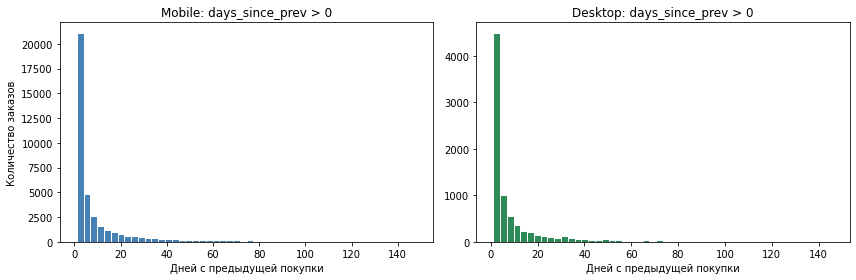

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mobile_gap, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Mobile: days_since_prev > 0')
axes[0].set_xlabel('Дней с предыдущей покупки')
axes[0].set_ylabel('Количество заказов')

axes[1].hist(desktop_gap, bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Desktop: days_since_prev > 0')
axes[1].set_xlabel('Дней с предыдущей покупки')

plt.tight_layout()
plt.show()

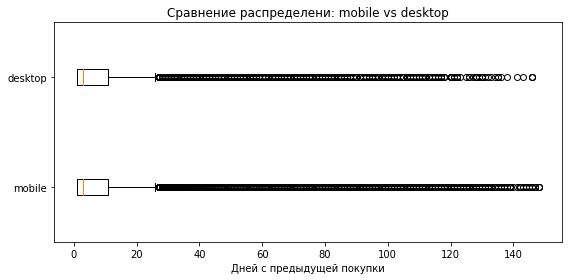

In [54]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([mobile_gap, desktop_gap], vert=False, labels=['mobile', 'desktop'])
ax.set_xlabel('Дней с предыдущей покупки')
ax.set_title('Сравнение распределени: mobile vs desktop')
plt.tight_layout()
plt.show()

**Промежуточный вывод:**<br>

У обоих типов устройств среднее количество дней с предыдущей покупки в разы больше медианы (mobile: 12.18 vs 3, desktop: 12 vs 3).<br>
Стандартное отклонение также в разы больше среднего (mobile: 21.79 vs 12.18, desktop: 21.74 vs 12). <br>
На графиках видно правосторонную асимметрию.<br>
На boxplot так же видно большое количество выбросов.
Распределения для обоих типов устройств почти идентичны.

Итого: данные не распределены нормально. t-тест не подойдёт.

Для статистической оценки будем использовать тест Манна-Уитни, потому что:
- данные не распределены нормально;
- он работает с рангами, а не средними - устойчив к оставшейся асимметрии;
- у него нет требований к выборкам, он подходит для сравнения двух независимых по устройству групп разного размера.

In [55]:
alpha = 0.05
result_gap = stats.mannwhitneyu(mobile_gap, desktop_gap, alternative='greater')

print(f'U-статистика: {result_gap.statistic:.1f}')
print(f'p-value: {result_gap.pvalue:.10f}')

if result_gap.pvalue < alpha:
    print('Отвергаем H0: время между заказами у mobile статистически значимо больше, чем у desktop')
else:
    print('Не удалось отвергнуть H0')

U-статистика: 165018955.5
p-value: 0.1847358352
Не удалось отвергнуть H0


**Промежуточный вывод по гипотезе про среднее время между заказами:**<br>

Перед тестом были исключены пропуски (первая покупка, нет истории) и заказы с `days_since_prev = 0` (повторные покупки в тот же день). Распределения интервалов между заказами оказались практически идентичны для mobile и desktop. Оба распределения имеют правостороннюю ассиметрию.<br>

Для сравнения групп использован тест Манна-Уитни - обоснование то же, что и в первой гипотезе. 

Результат: p-value = 0.185 (выше α = 0.05), следовательно H0 не отвергается. Статистически значимых различий во времени между заказами у пользователей mobile и desktop не обнаружено.<br>

### Вывод по 4 пункту

- Первая гипотеза (заказы на пользователя) подтвердилась - пользователи mobile статистически значимо активнее и чаще оформляют заказы, чем пользователи стационарных устройств.
- Вторая гипотеза (время между заказами) не подтвердилась - статистически значимой разницы нет, пользователи обоих типов устройств возвращаются за покупкой с одинаковой перодичностью.

## 5. Итоговый вывод и рекомендации

### Информация о данных

Анализ проведён на данных сервиса Яндекс Афиша за период с 1 июня по 31 октября 2024 года: 290 849 заказов билетов (`orders_df`), объединённых с данными о 22 427 мероприятиях (`events_df`) и курсом тенге к рублю (`tenge_df`). После предобработки (удаление 238 заказов без данных о мероприятии, 30 технических дублей, отсечение выбросов по 99-му процентилю выручки) в анализе осталось **~283 тыс. заказов**. Выручка приведена к единой валюте (`revenue_rub`), добавлены признаки сезона, месяца и выручки на один билет.

### Основные результаты анализа

**Рост спроса и сезонность.** Количество заказов монотонно росло весь период - с 34,2 тыс. в июне до 99,3 тыс. в октябре (почти x3), с явным переломом в сентябре (+56% к августу), обозначившим начало осеннего всплеска.

**Изменение популярности мероприятий (лето vs осень).** Наибольший рост доли заказов - у **спорта** (0.03 → 0.11, почти x4) и **театра** (0.20 → 0.25). Доля концертов снизилась (0.43 → 0.37), но они остаются самым популярным типом мероприятий в оба сезона. Осенняя аудитория заметно смещается в сторону семейного контента: доля 0+ выросла на треть (0.18 → 0.24), доля 18+ настолько же упала (0.15 → 0.10).

**Средний чек (выручка с одного билета).** Чёткой единой тенденции нет - динамика разнонаправленная по типам мероприятий: билеты подорожали на стендап (+5.8%) и выставки (+4.9%), подешевели на театр (-17.8%), ёлки (−15.4%) и концерты (-12.0%). Рост популярности театра сопровождался падением цены билета. У спорта, напротив, четырёхкратный рост доли заказов произошел без изменения цены, соответственно весь прирост дал объем, а не средний чек.

**Пользовательская активность осенью.** DAU устойчиво рос весь период - более чем в 2 раза (с ~550 до ~1250 пользователей в день), с выраженной недельной цикличностью. Активность (число заказов, DAU, заказы на пользователя) в будни стабильно выше, чем в выходные, а вот средний чек, наоборот, выше именно в выходные - вероятно, в выходные чаще покупают более дорогие билеты. Обнаружено 3 дня с аномальными всплесками заказов (в 3–4 раза выше нормы) на фоне резкого падения цены билета - скорее всего влияние акций.

**Лидеры среди регионов и партнёров.** Рынок заметно консолидирован в обоих разрезах:
- По регионам - топ-10 дают 72% заказов и 66% мероприятий, лидер - Каменевский регион (31% заказов, 27% мероприятий).
- По партнёрам - топ-10 дают 91% заказов, 87% мероприятий и 86% выручки, лидер - «Билеты без проблем» (21.84% заказов, 16.30% выручки).

### Результаты проверки гипотез

- **Гипотеза 1 (заказы на пользователя) подтвердилась.** После отсечения аномальных пользователей (99-й процентиль) тест Манна-Уитни показал, что пользователи mobile статистически значимо чаще оформляют заказы, чем пользователи desktop.
- **Гипотеза 2 (время между заказами) не подтвердилась.** Время между заказами у mobile и desktop оказались практически идентичны (совпадают медианы и большинство перцентилей) и тест Манна-Уитни не выявил значимой разницы.

### Рекомендации

1. **Готовиться к пику спроса заранее.** Рост заказов к осени устойчив и предсказуем (x3 к октябрю) - в будущем стоит заранее увеличивать мощности сервиса (поддержка, инфраструктура) и планировать промо-активности к сентябрю.
2. **Усилить фокус на спорт и семейный контент осенью.** Спорт и мероприятия 0+ показывают наибольший рост популярности - есть смысл расширять предложение и продвижение в этих категориях в осенний период.
3. **Пересмотреть ценовую политику для театра и концертов.** Падение среднего чека на фоне роста популярности (особенно у театра) стоит изучить отдельно, т.к. это потеря потенциальной выручки из-за скидок или демпинга цен партнерами.
4. **Диверсифицировать зависимость от лидеров рынка.** Концентрация на нескольких регионах и партнерах - это одновременно и точка роста, и риск зависимости от ключевых игроков. Стоит проанализировать причины отставания остальных регионов и партнеров.
5. **Развивать мобильное приложение как приоритетный канал.** Так как у mobile-пользователей подтвержденная более высокая активность по числу заказов, стоит продолжать инвестировать в мобльное приложение, UX, push-уведомления и мобильные акции. Так как сам по себе канал не влияет на частоту возвратов, то стоит фокусироваться именно на конверсии.